In [1]:
# Mount Google Drive so this notebook can reach the uploaded files
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Unzip the 10 second spectrograms from Drive into the fast local Colab disk
import zipfile, os

zip_path = "/content/drive/MyDrive/ai-music-detector/data/spectrograms_10s.zip" # where the zip lives on Drive

extract_to = "/content/spectrograms_10s" # unzip into Colab's own local disk (much faster to read from than Drive)

with zipfile.ZipFile(zip_path, "r") as z: # open the zip

    z.extractall(extract_to) # unpack all 1168 files

# check what landed
folders = sorted(os.listdir(extract_to))

print("Folders extracted:", folders)

for fol in folders:

    n = len(os.listdir(os.path.join(extract_to, fol)))

    print(f"  {fol}: {n} files")

Folders extracted: ['MusicGen_medium', 'audioldm2', 'musicldm', 'mustango', 'reals', 'stable_audio_open']
  MusicGen_medium: 200 files
  audioldm2: 200 files
  musicldm: 200 files
  mustango: 200 files
  reals: 168 files
  stable_audio_open: 200 files


In [3]:
# Imports for the model and evaluation
import torch

import torch.nn as nn

from torchvision import models

# Use the GPU if present (it is: we set the T4 runtime)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [4]:
# Rebuild the exact same ResNet18 shape used in training and then pour in the saved weights

model = models.resnet18(weights=None) # the ResNet18 skeleton, no pretrained weights (suppying own)

model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False) # front edge: accept 1 channel (spectrograms are greyscale) instead of 3

model.fc = nn.Linear(model.fc.in_features, 1) # back edge: 1 output (real vs fake) instead of 1000

# load the trained weights from Drive into this skeleton
weights_path = "/content/drive/MyDrive/ai-music-detector/cnn_resnet18_best.pth"

model.load_state_dict(torch.load(weights_path, map_location=device)) # pour the saved numbers into the matching slots

model = model.to(device) # move the model onto the GPU

model.eval() # switch to evaluation mode (no training behaviour)

print("Model loaded and in evaluation mode")

Model loaded and in evaluation mode


In [5]:
# Build a list of every spectrogram with its true label and its generator name
import numpy as np

eval_items = [] # each entry will be (file path, true label, generator name)

for fol in folders: # go through the six folders

    is_fake = 0 if fol == "reals" else 1 # reals are label 0, every generator folder is fake label 1

    fol_path = os.path.join(extract_to, fol) # full path to this folder

    for fname in sorted(os.listdir(fol_path)): # every .npy file in it. sorted for a stable order

        file_path = os.path.join(fol_path, fname) # full path to this one spectrogram

        eval_items.append((file_path, is_fake, fol)) # store the path, its label and which folder it came from

print("Total items:", len(eval_items)) # expecting 1168 (168 reals + 1000 fakes)

# quick sanity check: count how many of each label
n_real = sum(1 for item in eval_items if item[1] == 0)

n_fake = sum(1 for item in eval_items if item[1] == 1)

print("Reals:", n_real, " Fakes:", n_fake) # expecting 168 and 1000

Total items: 1168
Reals: 168  Fakes: 1000


In [6]:
# Run the model over every spectrogram and record its prediction
import torch.nn.functional as F

results = [] # each entry: (predicted label, true label, generator name)

with torch.no_grad(): # turn off gradient tracking as we are only predicting, not training (faster, less memory)

    for file_path, true_label, gen in eval_items: # walk all 1168 catalogued files

        spec = np.load(file_path) # load this spectrogram from disk: shape (128, 313)

        tensor = torch.tensor(spec).float().unsqueeze(0).unsqueeze(0) # to a tensor, add batch and channel dims: (1, 1, 128, 313)

        tensor = tensor.to(device) # move it onto the same GPU as the model

        logit = model(tensor) # the models raw output score for this one spectrogram

        prob = torch.sigmoid(logit).item() # squash the score to a 0..1 probability then unwrap to a plain number

        pred = 1 if prob >= 0.5 else 0 # decide: 0.5 or higher means fake (1), below means real (0)

        results.append((pred, true_label, gen)) # store the verdict alongside the truth and the generator

print("Predictions made:", len(results)) # expecting 1168

# quick look at the first few
for r in results[:5]:

    print(r)

Predictions made: 1168
(1, 1, 'MusicGen_medium')
(1, 1, 'MusicGen_medium')
(0, 1, 'MusicGen_medium')
(1, 1, 'MusicGen_medium')
(0, 1, 'MusicGen_medium')


In [7]:
# Per generator scores: how well the detector caught each unseen generators fakes
from sklearn.metrics import precision_score, recall_score, f1_score

# the five generator names (everything that is not the reals folder)
gen_names = [g for g in folders if g != "reals"]

# pull out the reals once: their predictions and truths (same 168 reals reused for every generator)
real_preds = [pred for pred, truth, gen in results if gen == "reals"]

real_truths = [truth for pred, truth, gen in results if gen == "reals"]

print(f"{'Generator':<20} {'Precision':>10} {'Recall':>10} {'F1':>10}")

print("-" * 52)

for g in gen_names: # one row per generator

    # this generators fake predictions and truths
    gen_preds = [pred for pred, truth, gen in results if gen == g]

    gen_truths = [truth for pred, truth, gen in results if gen == g]

    # combine this generators fakes with the shared reals to make a balanced test
    y_pred = gen_preds + real_preds

    y_true = gen_truths + real_truths

    # compute the three metrics for this generator vs reals
    p = precision_score(y_true, y_pred, zero_division=0)

    r = recall_score(y_true, y_pred, zero_division=0)

    f = f1_score(y_true, y_pred, zero_division=0)

    print(f"{g:<20} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

Generator             Precision     Recall         F1
----------------------------------------------------
MusicGen_medium          0.9697     0.3200     0.4812
audioldm2                0.9130     0.1050     0.1883
musicldm                 0.9583     0.2300     0.3710
mustango                 0.9759     0.4050     0.5724
stable_audio_open        0.9770     0.4250     0.5923


Confusion matrix:
[[166   2]
 [703 297]]

Reals called real (TN): 166
Reals called fake (FP): 2
Fakes called real (FN, missed): 703
Fakes called fake (TP, caught): 297


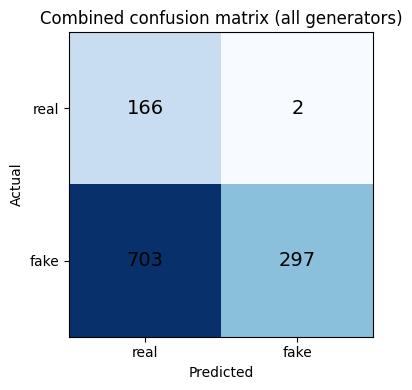

In [8]:
# Combined confusion matrix: all 1000 fakes and 168 reals pooled together
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

all_preds = [pred for pred, truth, gen in results] # every prediction, all 1168

all_truths = [truth for pred, truth, gen in results] # every true label, all 1168

cm = confusion_matrix(all_truths, all_preds) # build the 2 x 2 grid of counts

print("Confusion matrix:")

print(cm)

# unpack the four cells for a plain english readout
tn, fp, fn, tp = cm.ravel() # true neg, false pos, false neg, true pos

print(f"\nReals called real (TN): {tn}")

print(f"Reals called fake (FP): {fp}")

print(f"Fakes called real (FN, missed): {fn}")

print(f"Fakes called fake (TP, caught): {tp}")

# draw it
fig, ax = plt.subplots(figsize=(5, 4))

ax.imshow(cm, cmap="Blues") # colour the cells by count

ax.set_xticks([0, 1]); ax.set_xticklabels(["real", "fake"])

ax.set_yticks([0, 1]); ax.set_yticklabels(["real", "fake"])

ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

ax.set_title("Combined confusion matrix (all generators)")

# write the number in each cell
for i in range(2):

    for j in range(2):

        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

plt.tight_layout()

plt.show()

In [9]:
# Grad-CAM: produce a heatmap showing which regions drove the models decision
import torch.nn.functional as F

def grad_cam(spec_path):

    spec = np.load(spec_path) # load the spectrogram: shape (128, 313)

    tensor = torch.tensor(spec).float().unsqueeze(0).unsqueeze(0).to(device) # to (1, 1, 128, 313) on the GPU

    # storage for what the hooks catch
    activations = {} # the feature maps from layer4 (what the model saw)

    gradients = {} # the gradients flowing back through layer4 (what mattered)

    # forward hook: grab layer4's output as the spectrogram passes through
    def save_activation(module, inp, out):

        activations["value"] = out

    # backward hook: grab the gradients as they flow back through layer4
    def save_gradient(module, grad_in, grad_out):

        gradients["value"] = grad_out[0]

    # attach both hooks to the last conv block
    h1 = model.layer4.register_forward_hook(save_activation)

    h2 = model.layer4.register_full_backward_hook(save_gradient)

    # forward pass: get the model's score for this spectrogram
    logit = model(tensor)

    # backward pass: push the score back to see which features drove it
    model.zero_grad()

    logit.backward()

    # remove the hooks now that we have whats needed
    h1.remove()

    h2.remove()

    # pull out the caught tensors
    acts = activations["value"][0] # shape (512, 4, 10): 512 feature maps

    grads = gradients["value"][0] # shape (512, 4, 10): their gradients

    # weight each feature map by its average gradient (how much it mattered)
    weights = grads.mean(dim=(1, 2)) # one weight per feature map: shape (512,)

    # combine the maps by those weights into a single heatmap
    cam = torch.zeros(acts.shape[1:], device=device) # blank heatmap: shape (4, 10)

    for i, w in enumerate(weights):

        cam += w * acts[i] # add each weighted feature map

    cam = F.relu(cam) # keep only positive influence (regions that pushed toward the decision)

    cam = cam / (cam.max() + 1e-8) # normalise to 0 to 1 for display. the 1e-8 is a safe guard so it never ends up dividing by zero

    return spec, cam.detach().cpu().numpy() # return the spectrogram and its heatmap

print("grad_cam function ready") # this is just to check that it all went through okay

grad_cam function ready


In [10]:
# Call grad_cam on real_03580 (the FR-005 false positive) and overlay the heatmap
import matplotlib.pyplot as plt

# find real_03580's spectrogram in the reals folder
target = "real_03580"

real_folder = os.path.join(extract_to, "reals") # extract_to = "/content/spectrograms_10s", so this is the reals folder

match = [f for f in os.listdir(real_folder) if target in f] # look for the file whose name contains real_03580

print("Matching files:", match) # should show exactly one .npy file

Matching files: ['real_03580.npy']


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Spectrogram shape: (128, 313)
Heatmap shape: (4, 10)


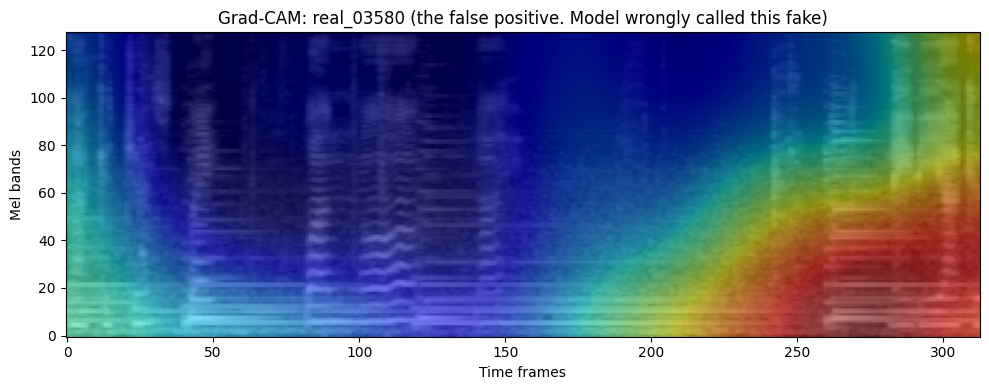

In [11]:
# Run Grad-CAM on real_03580 and overlay the heatmap on its spectrogram
import numpy as np

spec_path = os.path.join(real_folder, "real_03580.npy") # full path to the file we just found

spec, heatmap = grad_cam(spec_path) # The call: sends this spectrogram through and gets back (spectrogram, heatmap)

print("Spectrogram shape:", spec.shape) # (128, 313)

print("Heatmap shape:", heatmap.shape) # (4, 10) - tiny. will be stretched to overlay

# stretch the tiny (4,10) heatmap up to the spectrogram's (128,313) size
from scipy.ndimage import zoom

scale_h = spec.shape[0] / heatmap.shape[0] # 128 / 4 = 32

scale_w = spec.shape[1] / heatmap.shape[1] # 313 / 10 = 31.3

heatmap_big = zoom(heatmap, (scale_h, scale_w)) # smoothly resize the heatmap to (128, 313)

# draw the spectrogram with the heatmap on top
fig, ax = plt.subplots(figsize=(10, 4)) # first draw the blank canvas for them to go on

ax.imshow(spec, aspect="auto", origin="lower", cmap="gray") # the spectrogram in greyscale underneath. origin="lower" to make sure it puts row zero on bottom

ax.imshow(heatmap_big, aspect="auto", origin="lower", cmap="jet", alpha=0.5) # heatmap on top. half see through

ax.set_title("Grad-CAM: real_03580 (the false positive. Model wrongly called this fake)")

ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bands")

plt.tight_layout()

plt.show()

In [12]:
# Find one missed fake (model said real) and one caught fake (model said fake) to compare
# results holds (pred, true_label, gen) for all 1168. reminder: pred/truth 1=fake, 0=real, gen=folder name

missed = None # will hold a fake the model wrongly called real

caught = None # will hold a fake the model correctly called fake

for idx, (pred, true_label, gen) in enumerate(results): # walk all 1168 predictions. idx = position in the list

    if true_label == 1 and pred == 0 and missed is None: # a fake (truth 1) called real (pred 0) = a miss

        missed = (idx, gen) # remember its position and which generator

    if true_label == 1 and pred == 1 and caught is None: # a fake (truth 1) called fake (pred 1) = caught

        caught = (idx, gen) # remember its position and generator

    if missed and caught: # stop once we have one of each

        break

print("Missed example:", missed) # (position in results, generator name)

print("Caught example:", caught)

Missed example: (2, 'MusicGen_medium')
Caught example: (0, 'MusicGen_medium')


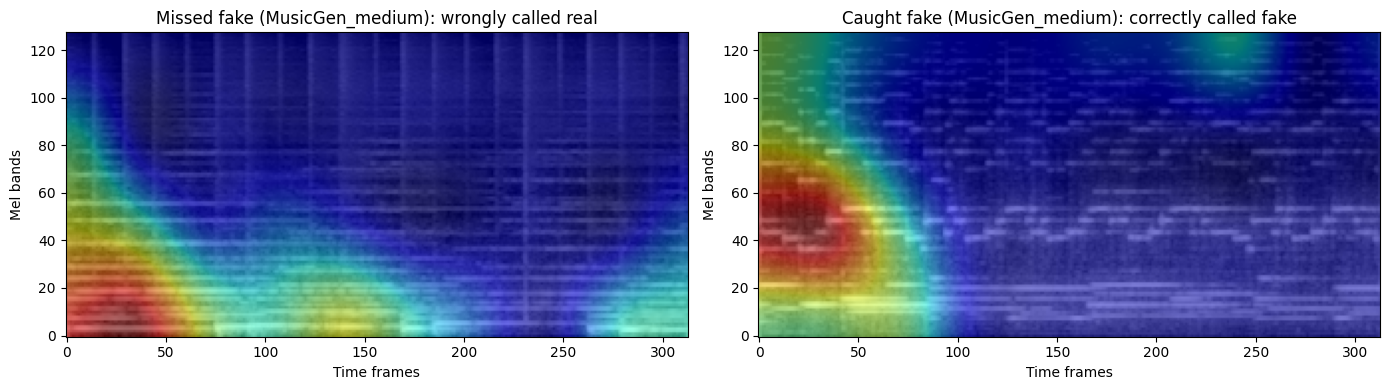

In [13]:
# Grad-CAM on a missed fake vs a caught fake side by side (the recall gap picture)
from scipy.ndimage import zoom

# pull the position and generator out of each example the finder saved
missed_idx, missed_gen = missed # a fake the model wrongly called real

caught_idx, caught_gen = caught # a fake the model correctly called fake

# the position doubles as the index into eval_items (same order as results)
missed_path = eval_items[missed_idx][0] # eval_items entry is (path, label, gen), so [0] is the path

caught_path = eval_items[caught_idx][0]

# run the engine on each: get back its spectrogram and heatmap
missed_spec, missed_heat = grad_cam(missed_path)

caught_spec, caught_heat = grad_cam(caught_path)

# stretch each tiny (4,10) heatmap up to its spectrogram's (128,313) size
missed_big = zoom(missed_heat, (missed_spec.shape[0] / missed_heat.shape[0],
                                missed_spec.shape[1] / missed_heat.shape[1]))

caught_big = zoom(caught_heat, (caught_spec.shape[0] / caught_heat.shape[0],
                                caught_spec.shape[1] / caught_heat.shape[1]))

# draw the two side by side: one row, two columns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left panel: the missed fake
axes[0].imshow(missed_spec, aspect="auto", origin="lower", cmap="gray")

axes[0].imshow(missed_big, aspect="auto", origin="lower", cmap="jet", alpha=0.5)

axes[0].set_title(f"Missed fake ({missed_gen}): wrongly called real")

axes[0].set_xlabel("Time frames"); axes[0].set_ylabel("Mel bands")

# right panel: the caught fake
axes[1].imshow(caught_spec, aspect="auto", origin="lower", cmap="gray")

axes[1].imshow(caught_big, aspect="auto", origin="lower", cmap="jet", alpha=0.5)

axes[1].set_title(f"Caught fake ({caught_gen}): correctly called fake")

axes[1].set_xlabel("Time frames"); axes[1].set_ylabel("Mel bands")

plt.tight_layout()

plt.show()

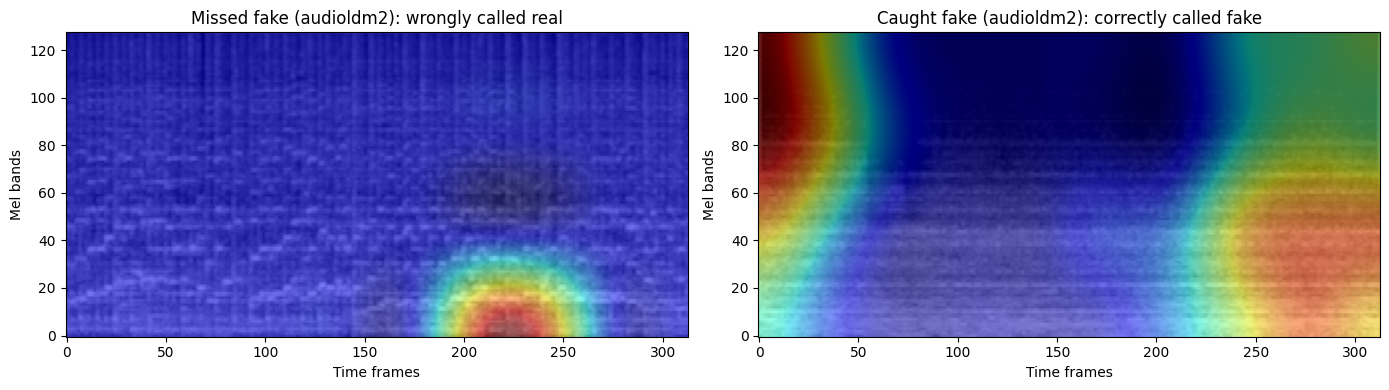

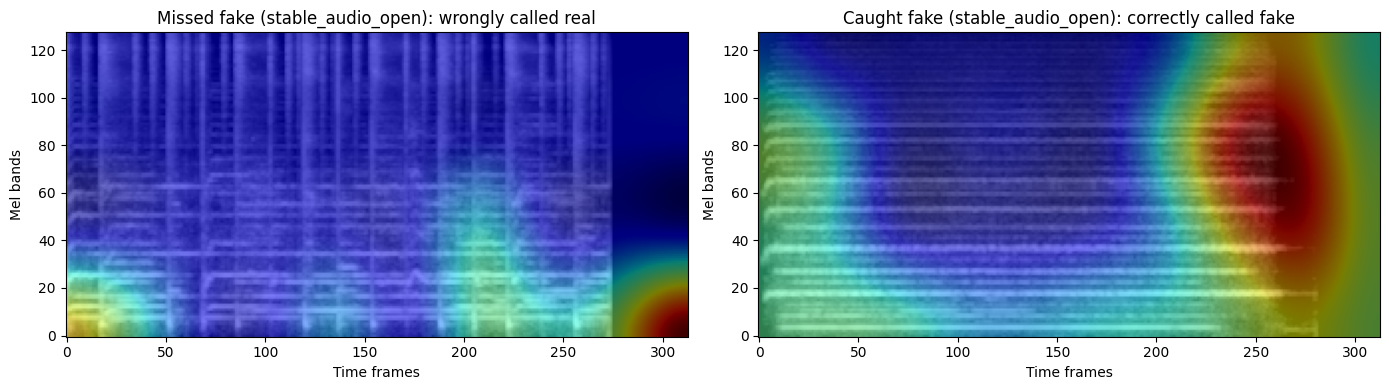

In [14]:
# Confirm the pattern holds: draw a missed vs caught pair for two more generators
from scipy.ndimage import zoom

def show_pair(gen_name):

    # find the first missed and first caught fake for this generator
    m_idx = c_idx = None

    for idx, (pred, true_label, gen) in enumerate(results): # walk all 1168 verdicts

        if gen != gen_name: # skip rows that aren't this generator
            continue

        if pred == 0 and m_idx is None: # this generators fake called real = a miss
            m_idx = idx

        if pred == 1 and c_idx is None: # called fake = caught
            c_idx = idx

        if m_idx is not None and c_idx is not None: # one of each found so stop
            break

    # get the file paths (eval_items shares the same order as results)
    m_path = eval_items[m_idx][0]

    c_path = eval_items[c_idx][0]

    # run the engine on each: spectrogram + heatmap
    m_spec, m_heat = grad_cam(m_path)

    c_spec, c_heat = grad_cam(c_path)

    # stretch each tiny (4,10) heatmap up to (128,313)
    m_big = zoom(m_heat, (m_spec.shape[0] / m_heat.shape[0], m_spec.shape[1] / m_heat.shape[1]))

    c_big = zoom(c_heat, (c_spec.shape[0] / c_heat.shape[0], c_spec.shape[1] / c_heat.shape[1]))

    # draw the two side by side
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].imshow(m_spec, aspect="auto", origin="lower", cmap="gray")

    axes[0].imshow(m_big, aspect="auto", origin="lower", cmap="jet", alpha=0.5)

    axes[0].set_title(f"Missed fake ({gen_name}): wrongly called real")

    axes[0].set_xlabel("Time frames"); axes[0].set_ylabel("Mel bands")

    axes[1].imshow(c_spec, aspect="auto", origin="lower", cmap="gray")

    axes[1].imshow(c_big, aspect="auto", origin="lower", cmap="jet", alpha=0.5)

    axes[1].set_title(f"Caught fake ({gen_name}): correctly called fake")

    axes[1].set_xlabel("Time frames"); axes[1].set_ylabel("Mel bands")

    plt.tight_layout()

    plt.show()

# two more generators to check the pattern generalises
show_pair("audioldm2")

show_pair("stable_audio_open")

In [15]:
# Aggregate Grad-CAM over all fakes to test for a real pattern (not just eyeballing pairs)
import numpy as np

heatmaps = [] # the (4,10) heatmap for each fake

gens = [] # its generator name

correct = [] # True if caught (pred==1), False if missed (pred==0)

for (pred, true_label, gen), (path, _, _) in zip(results, eval_items): # results and eval_items share order

    if true_label != 1: # only fakes have a missed/caught split, skip reals
        continue

    _, cam = grad_cam(path) # run the engine, keep just the (4,10) heatmap

    heatmaps.append(cam)

    gens.append(gen)

    correct.append(pred == 1) # caught = the model called it fake

heatmaps = np.array(heatmaps) # shape (1000, 4, 10)

gens = np.array(gens)

correct = np.array(correct)

print("Heatmaps collected:", heatmaps.shape)

print("Caught:", int(correct.sum()), " Missed:", int((~correct).sum()))

Heatmaps collected: (1000, 4, 10)
Caught: 297  Missed: 703


Mean spread   caught: 0.318    missed: 0.100
(lower = more concentrated. if the two are close, there is no real difference)

generator             spread   caught%
MusicGen_medium        0.179     32.0%
audioldm2              0.090     10.5%
musicldm               0.150     23.0%
mustango               0.184     40.5%
stable_audio_open      0.222     42.5%


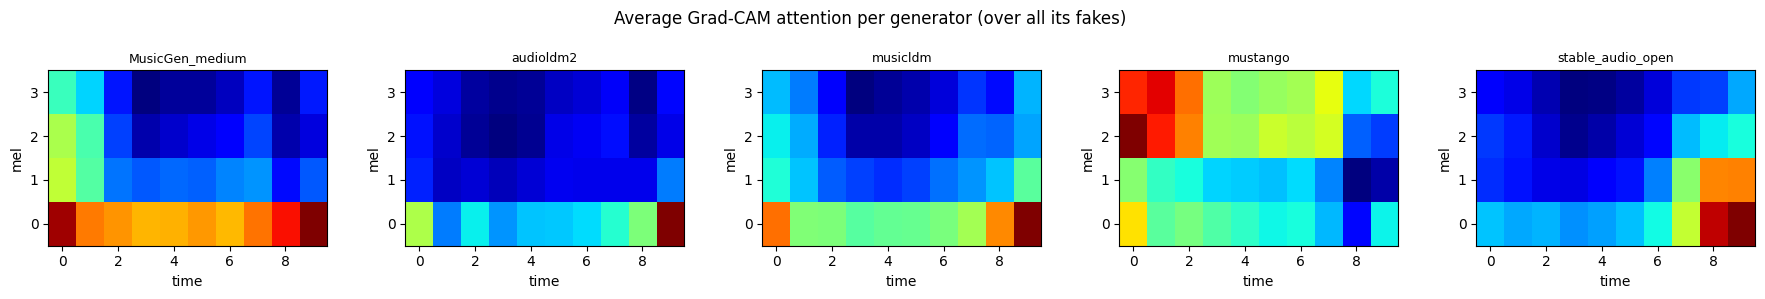

In [16]:
# Read the aggregates: is attention concentrated and does it land anywhere consistent
import matplotlib.pyplot as plt

# spread score per heatmap: mean of the max-normalised map. low = concentrated high = diffuse
spread = heatmaps.reshape(len(heatmaps), -1).mean(axis=1) # one number per fake

print("Mean spread   caught: %.3f    missed: %.3f" % (spread[correct].mean(), spread[~correct].mean()))

print("(lower = more concentrated. if the two are close, there is no real difference)\n")

# per generator: mean spread and its catch rate
gen_names = ["MusicGen_medium", "audioldm2", "musicldm", "mustango", "stable_audio_open"]

print(f"{'generator':<20}{'spread':>8}{'caught%':>10}")

for g in gen_names:

    mask = gens == g

    print(f"{g:<20}{spread[mask].mean():>8.3f}{100 * correct[mask].mean():>9.1f}%")

# average heatmap per generator: where does attention fall on average for each
fig, axes = plt.subplots(1, 5, figsize=(18, 3))

for ax, g in zip(axes, gen_names):

    avg = heatmaps[gens == g].mean(axis=0) # mean (4,10) map over this generators 200 fakes

    ax.imshow(avg, aspect="auto", origin="lower", cmap="jet")

    ax.set_title(g, fontsize=9)

    ax.set_xlabel("time"); ax.set_ylabel("mel")

plt.suptitle("Average Grad-CAM attention per generator (over all its fakes)")

plt.tight_layout()

plt.show()

In [17]:
# Control setup: bring in the 15-second Suno/Udio spectrograms (the models home turf)
# These are the original SONICS files, shape (128, 469) a separate set from this notebooks 10s FakeMusicCaps data
import os, pandas as pd

# copy the SONICS spectrogram zip off Drive and unzip to local disk (the same warm up the training notebook used)
!cp /content/drive/MyDrive/ai-music-detector/data/spectrograms.zip /content/

!unzip -q -o /content/spectrograms.zip -d /content/  # unzips flat into /content/spectrograms/

# load the same train/val/test split the CNN used (straight from the public repo)
splits_url = "https://raw.githubusercontent.com/cianbond/ai-music-detector/main/data/subset_splits.csv"

splits = pd.read_csv(splits_url)

# keep only fakes from the test split (not seen in training) whose spectrogram is actually on disk
fake_test = splits[(splits["filename"].str.startswith("fake_")) & (splits["split"] == "test")].copy()

fake_test["path"] = ["/content/spectrograms/" + name + ".npy" for name in fake_test["filename"]]

fake_test = fake_test[[os.path.exists(p) for p in fake_test["path"]]] # drop any that failed to download

# the source tool (suno or udio) is right there in the filename so split on it
suno = [p for p, n in zip(fake_test["path"], fake_test["filename"]) if "suno" in n]

udio = [p for p, n in zip(fake_test["path"], fake_test["filename"]) if "udio" in n]

print("Fake test spectrograms on disk:", len(fake_test))

print("  Suno:", len(suno), " Udio:", len(udio))

print("Examples:", [os.path.basename(p) for p in suno[:2] + udio[:2]])

Fake test spectrograms on disk: 202
  Suno: 96  Udio: 106
Examples: ['fake_53685_suno_1.npy', 'fake_40099_suno_0.npy', 'fake_54002_udio_0.npy', 'fake_30904_udio_1.npy']


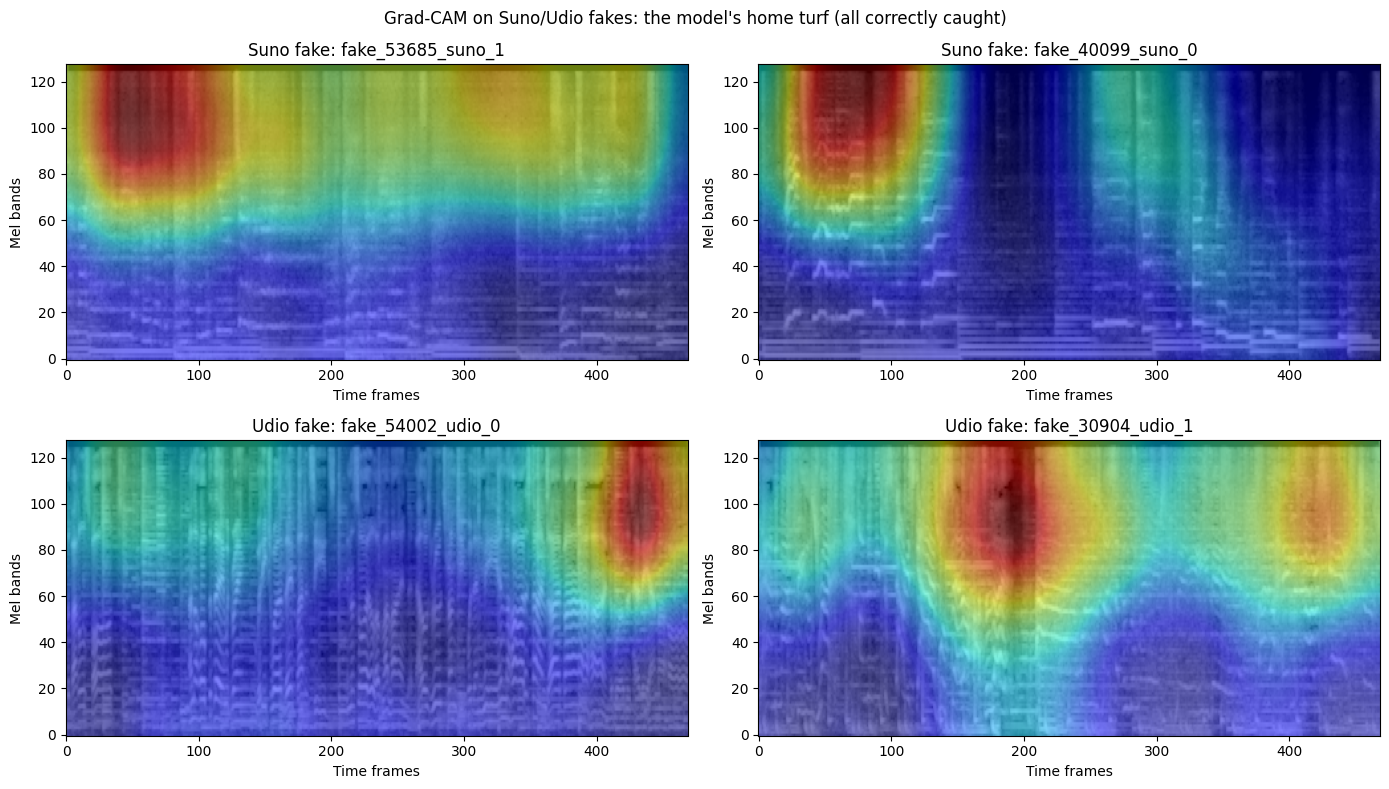

In [18]:
# Grad-CAM for two Suno and two Udio fakes: attention on easy ones (these are all correctly caught)
from scipy.ndimage import zoom

picks = suno[:2] + udio[:2] # four easy fakes

fig, axes = plt.subplots(2, 2, figsize=(14, 8)) # 2 x 2 grid of panels

axes = axes.ravel() # flatten the grid to a simple list of 4 axes

for ax, path in zip(axes, picks): # one panel per fake

    spec, heat = grad_cam(path) # same engine: hands back the (128,469) spectrogram and its (4,15) heatmap

    big = zoom(heat, (spec.shape[0] / heat.shape[0], spec.shape[1] / heat.shape[1])) # stretch heatmap up to spectrogram size

    ax.imshow(spec, aspect="auto", origin="lower", cmap="gray") # spectrogram underneath

    ax.imshow(big, aspect="auto", origin="lower", cmap="jet", alpha=0.5) # heatmap on top, half see through

    name = os.path.basename(path).replace(".npy", "") # filename for the title

    tool = "Suno" if "suno" in name else "Udio" # which generator made it

    ax.set_title(f"{tool} fake: {name}")

    ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bands")

plt.suptitle("Grad-CAM on Suno/Udio fakes: the model's home turf (all correctly caught)")

plt.tight_layout()

plt.show()

In [19]:
# Save the three Grad-CAM figures for the report
import os
from scipy.ndimage import zoom

# make a figures folder on Drive (permanent, survives the session)
fig_dir = "/content/drive/MyDrive/ai-music-detector/figures"

os.makedirs(fig_dir, exist_ok=True)

# helper: run the engine and stretch its heatmap up to full spectrogram size
def cam_overlay(path):

    spec, heat = grad_cam(path)

    big = zoom(heat, (spec.shape[0] / heat.shape[0], spec.shape[1] / heat.shape[1]))

    return spec, big

# Figure 1: real_03580, the FR-005 false positive
spec, big = cam_overlay(os.path.join(extract_to, "reals", "real_03580.npy"))

fig, ax = plt.subplots(figsize=(10, 4))

ax.imshow(spec, aspect="auto", origin="lower", cmap="gray")

ax.imshow(big, aspect="auto", origin="lower", cmap="jet", alpha=0.5)

ax.set_title("Grad-CAM: real_03580 (false positive, model wrongly called this fake)")

ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bands")

fig.savefig(f"{fig_dir}/gradcam_real_03580.png", dpi=150, bbox_inches="tight")

plt.close(fig) # close so it only saves (you have already seen it above)

# Figure 2: average attention per unseen generator
gen_names = ["MusicGen_medium", "audioldm2", "musicldm", "mustango", "stable_audio_open"]

fig, axes = plt.subplots(1, 5, figsize=(18, 3))

for ax, g in zip(axes, gen_names):

    avg = heatmaps[gens == g].mean(axis=0) # mean heatmap over this generator's fakes

    ax.imshow(avg, aspect="auto", origin="lower", cmap="jet")

    ax.set_title(g, fontsize=9)

    ax.set_xlabel("time"); ax.set_ylabel("mel")

fig.suptitle("Average Grad-CAM attention per generator (over all its fakes)")

fig.savefig(f"{fig_dir}/gradcam_avg_per_generator.png", dpi=150, bbox_inches="tight")

plt.close(fig)

# Figure 3: Suno/Udio
picks = suno[:2] + udio[:2]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes = axes.ravel()

for ax, path in zip(axes, picks):

    spec, big = cam_overlay(path)

    ax.imshow(spec, aspect="auto", origin="lower", cmap="gray")

    ax.imshow(big, aspect="auto", origin="lower", cmap="jet", alpha=0.5)

    name = os.path.basename(path).replace(".npy", "")

    tool = "Suno" if "suno" in name else "Udio"

    ax.set_title(f"{tool} fake: {name}")

    ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bands")

fig.suptitle("Grad-CAM on Suno/Udio fakes: the model's home turf (all correctly caught)")

fig.savefig(f"{fig_dir}/gradcam_suno_udio_home.png", dpi=150, bbox_inches="tight")

plt.close(fig)

# confirm the three files landed
print("Saved figures:")

!ls -lh /content/drive/MyDrive/ai-music-detector/figures/

Saved figures:
total 1.5M
-rw------- 1 root root  49K Jul 21 21:46 gradcam_avg_per_generator.png
-rw------- 1 root root 132K Jul 21 21:46 gradcam_real_03580.png
-rw------- 1 root root 1.4M Jul 21 21:46 gradcam_suno_udio_home.png


In [20]:
# Overfitting check: model accuracy on the train split vs the held out test split
# A large train over test gap means overfitting. A tiny gap means it generalises within Suno/Udio.
import numpy as np, torch, os

# reminder: splits = the full train/val/test table, model = the loaded detector,
# device = the GPU, /content/spectrograms/ = the 15 second SONICS spectrograms (all unzipped earlier)

def accuracy_on_split(split_name):

    rows = splits[splits["split"] == split_name] # just this splits rows

    paths = ["/content/spectrograms/" + name + ".npy" for name in rows["filename"]] # where each spectrogram lives

    labels = list(rows["target"]) # the true label per row (1 fake, 0 real)

    correct = total = 0

    with torch.no_grad(): # no learning here only predicting

        for path, true_label in zip(paths, labels):

            if not os.path.exists(path): # skip any track whose download failed
                continue

            spec = np.load(path) # the (128, 469) spectrogram

            tensor = torch.tensor(spec).float().unsqueeze(0).unsqueeze(0).to(device) # shape it for the model

            logit = model(tensor) # raw score

            pred = 1 if torch.sigmoid(logit).item() >= 0.5 else 0 # verdict at the 0.5 cutoff

            correct += (pred == true_label) # tally correct predictions

            total += 1

    return correct / total, total

train_acc, n_train = accuracy_on_split("train") # accuracy on data it learned from

test_acc, n_test = accuracy_on_split("test") # accuracy on held out data it never saw

print(f"Train accuracy: {train_acc:.4f}  (n={n_train})")

print(f"Test accuracy:  {test_acc:.4f}  (n={n_test})")

print(f"Gap (train - test): {train_acc - test_acc:.4f}")

Train accuracy: 0.9987  (n=2969)
Test accuracy:  0.9973  (n=370)
Gap (train - test): 0.0014
